#Churn Prediction for StreamWorks Media

###1. Data Loading and Initial Exploration

The Streamworks customer dataset was loaded using pandas.
Initial exploration was conducted to understand the dataset structure, data types, presence of missing values, and the target variable for churn prediction.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/streamworks_user_data.csv")
df.head()

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   object 
 3   signup_date           1498 non-null   object 
 4   last_active_date      1498 non-null   object 
 5   country               1497 non-null   object 
 6   subscription_type     1497 non-null   object 
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   object 
 11  referred_by_friend    1497 non-null   object 
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), object(7)
memory usage: 164.2+ KB


###Descriptive statistics

- it was made to summarise the central tendency and dispersion of numerical variables in the dataset
- it provides an overview of typical user behaviour and highlights potential variability across features

In [ ]:
df.describe()

,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
count,1498.000000,1497.000000,1496.000000,1498.000000,1497.000000,1499.000000,1355.000000
mean,1750.871829,43.738811,39.903342,51.414419,2.498330,0.234156,10.180406
std,433.060980,15.083920,22.978288,28.580117,1.706829,0.423612,3.310705
min,1001.000000,18.000000,0.500000,0.000000,0.000000,0.000000,5.990000
25%,1376.250000,31.000000,19.450000,27.100000,1.000000,0.000000,5.990000
50%,1750.500000,44.000000,40.300000,52.700000,2.000000,0.000000,9.990000
75%,2125.750000,56.000000,59.800000,76.200000,4.000000,0.000000,13.990000
max,2500.000000,69.000000,79.900000,100.000000,5.000000,1.000000,14.990000


####Key Observations from Initial Exploration

- dataset contains **1,500 rows and 14 columns**, with each row representing a unique user.
- target variable 'is_churned' is binary (1 = churned, 0 = retained)
- several columns contain **missing values**, including:
  - 'monthly_fee'
  - 'average_watch_hours'
  - 'age'
  - 'complaints_raised'
- date field ('signup_date', 'last_active_date') are currently stored as **object types** and will need to be converted to datetime format
- there is a mix of **numerical and categorical variables**, indicating the need for feature encoding during preprocessing

- average user age is approx. mid-40s, with users ranging from young adults to seniors
- average watch time and tenure show wide variability, indicating diverse engagement levels across users
- monthly subscription fees vary by plan, with a median close to the standard-tier pricing
- churn rate is approx. 23%, confirming a moderate class imbalance in the target variable.


In [ ]:
df['is_churned'].value_counts(normalize=True)

,proportion
is_churned,
0.0,0.765844
1.0,0.234156


####Churn Distribution
- approximately **76.6%** of users are retained, while **23.4%** have churned
- this indicates a moderate class imbalance, and relying on accuracy would be misleading,and require additional metrics such as precision, recall, F1-score and ROC-AUC will be used to properly evaluate model performance

###2. Data Cleaning and Preprocessing
- data quality issues were identified during initial exploration are addressed
- includes checking for duplicate records, correcting data types, handling missing values and preparing for feature engineering and data predictive modelling

In [ ]:
df.duplicated().sum()

np.int64(0)

####2.1 Duplicate Records check
- duplicate check was performed to ensure that each row represents a unique user
- no duplicate records were found, confirming that the dataset does not contain redundant rows

####2.2 Datetime Conversion
- 'signup_date' and 'last_active_date' columns were converted from object datatypes to datetime format using an explicit date format (DD-MM-YY)
- this is required to calculate tenure-based features such as the number of days a user has been active

In [ ]:
df['signup_date'] = pd.to_datetime(df['signup_date'], format="%d-%m-%y")
df['last_active_date'] = pd.to_datetime(df['last_active_date'], format="%d-%m-%y")
df[['signup_date', 'last_active_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   signup_date       1498 non-null   datetime64[ns]
 1   last_active_date  1498 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 23.6 KB


 both date columns were converted to datetime format, enabling time-based calculations in subsequent feature engineering steps

####2.3 Handling missing values
- several columns in this dataset contain missing values. these were reviewed carefully and appropriate strategies were applied to handle missing data while minimising information loss and avoiding bias in the analysis

In [ ]:
df.isnull().sum()

,0
user_id,2
age,3
gender,1
signup_date,2
last_active_date,2
country,3
subscription_type,3
average_watch_hours,4
mobile_app_usage_pct,2
complaints_raised,3


- to handle missing values, a combination of row removal and imputation is used
- rows missing critical identifiers, date fields or the target variable are removed
- for numerical features, missing values were filled using the median to reduce the impact of outliers
- categorical features were imputed using the most frequent values

In [ ]:
df = df.dropna(subset=['user_id', 'signup_date', 'last_active_date', 'is_churned'])

In [ ]:
numeric_cols = ['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised', 'monthly_fee']
for col in numeric_cols:
  df[col] = df[col].fillna(df[col].median())

In [ ]:
categorical_cols = ['gender', 'country', 'subscription_type', 'received_promotions', 'referred_by_friend']
for col in categorical_cols:
  df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
signup_date,0
last_active_date,0
country,0
subscription_type,0
average_watch_hours,0
mobile_app_usage_pct,0
complaints_raised,0


after applying the above strategies, no missing values remain in the dataset

the data can now be used for feature engineering and statiscal analysis

####2.4 Data type corrections
- final data type check is performed to ensure consistency across the dataset
identifier and target variable were converted to appropriate integer types to support reliable analysis and modelling

In [ ]:
df['user_id'] = df['user_id'].astype(int)
df['is_churned'] = df['is_churned'].astype(int)
df[['user_id', 'is_churned']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1493 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     1493 non-null   int64
 1   is_churned  1493 non-null   int64
dtypes: int64(2)
memory usage: 35.0 KB


'user_id' and 'is_churned' columns were converted into integer data types

the dataset can now be used for feature engineering

####Correlation matrix analysis
- a correlation analysis is performed on the numerical variables to identify linear relationships between user behaviour, subscription characteristics and churn
- this helps highlight potential predictors for the churn model

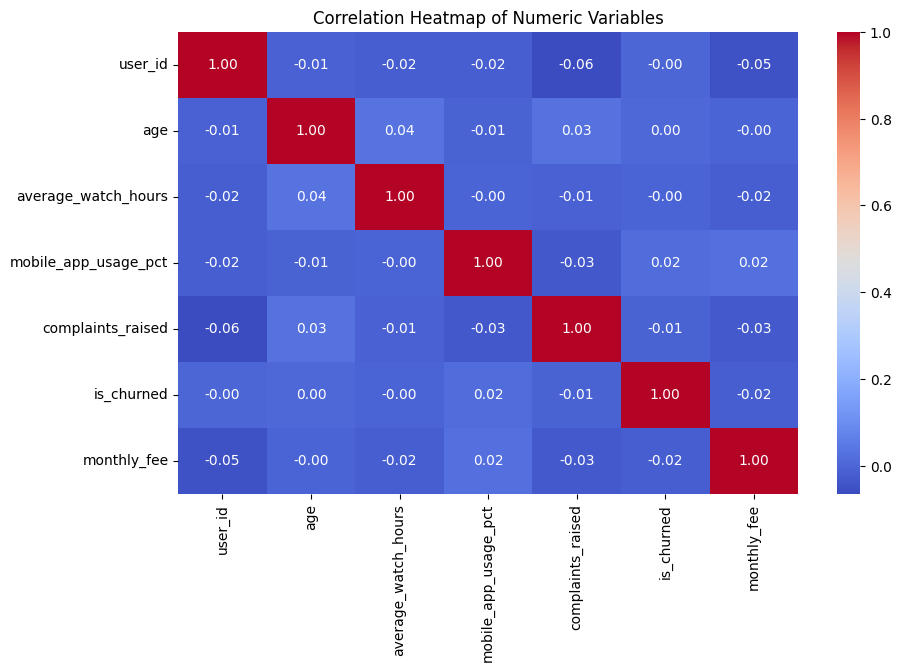

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

- correlation heatmap indicates that most numerical variables have weak linear relationships with each other and with the churn variable
- no single feature shows a strong correlation with 'is_churned', suggesting that churn behaviour is influenced by a combination of factors rather than one dominant variable
- this suppports the user of multivariate models such as logistic regression, which can capture combined effects that are not visible through pairwise correlation alone

####3. Feature engineering
- feature engineering is performed to create new variables that capture user behaviour and engagement more effectively
- these features help improve statistical analysis and predictive modelling

####3.1 Tenure calculation
- user tenure is calculated as the number of days between the signup date and last active date
- tenue is a key indicator of cutomer loyalty and is expected to influence churn behaviour

In [ ]:
df['tenure_days'] = (df['last_active_date'] - df['signup_date']).dt.days
df[['signup_date', 'last_active_date', 'tenure_days']].head()

,signup_date,last_active_date,tenure_days
0,2025-04-02,2025-07-13,102
1,2023-01-02,2025-07-13,923
2,2022-08-21,2025-07-13,1057
3,2023-09-14,2025-07-13,668
4,2023-07-29,2025-07-13,715


'tenure_days' feature was created and represents the length of time each user has been active on the platform
- short tenure (102 days) = newer user
- long tenure (900_ days) = long-term subscriber

####3.2 Loyalty indicator
- binary loyalty feature is created to identify long-term users
- users with a tenure greater than 180 days were classified as loyal
- this threshold helps distiguish between newer users and established customers

In [ ]:
df['is_loyal'] = (df['tenure_days'] >180).astype(int)
df[['tenure_days', 'is_loyal']].head(10)

,tenure_days,is_loyal
0,102,0
1,923,1
2,1057,1
3,668,1
4,715,1
5,749,1
6,879,1
7,936,1
8,44,0
9,248,1


'is_loyal' feature assigns a value of 1 to users with more than 180 days of tenure and 0 otherwise

this feature will be useful for analysing churn patterns among long-term vs newer users

####4. Encoding categorical features
- ml models require numerical outputs
- categorical variables are encoded into numerical formats to make them suitable for statistical analysis and predictive modelling

####4.1 One-Hot encoding
- nominal categorical variables are encoded using on-hot encoding to avoid introducing any unintended ordinal relationships between categories

In [ ]:
categorical_cold = ['gender', 'country', 'subscription_type', 'received_promotions', 'referred_by_friend']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,user_id,age,signup_date,last_active_date,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee,tenure_days,...,gender_Other,country_France,country_Germany,country_India,country_UK,country_USA,subscription_type_Premium,subscription_type_Standard,received_promotions_Yes,referred_by_friend_Yes
0,1001,56.0,2025-04-02,2025-07-13,42.6,77.4,1.0,1,10.99,102,...,True,True,False,False,False,False,False,True,False,False
1,1002,69.0,2023-01-02,2025-07-13,65.3,98.0,4.0,1,5.99,923,...,False,False,False,True,False,False,False,False,False,True
2,1003,46.0,2022-08-21,2025-07-13,40.1,47.8,0.0,1,13.99,1057,...,False,False,False,False,True,False,True,False,False,True
3,1004,32.0,2023-09-14,2025-07-13,5.8,53.2,1.0,1,13.99,668,...,True,False,True,False,False,False,True,False,True,True
4,1005,60.0,2023-07-29,2025-07-13,32.7,16.8,5.0,0,9.99,715,...,False,False,False,True,False,False,False,True,False,True


categorical variables changed using ont-hot encoding

the dataset now consists entirely of numerical features and is ready for statistical testing and predictive modelling

####5. Statistical analysis and insights
- statistical tests were conducted to examine relationships between customer characteristics and churn
- these tests help determine whether observed influences are statistically significant or likely due to chance

####5.1 Statistical tests (Chi-square & T-test)
#####5.1.1 Chi-square tests for categorical variables
- chi-square tests are used to assess whether churn is significantly associated with selected categorical variables
- this test is appropriate for examining relationships between two categorical variables

In [ ]:
from scipy.stats import chi2_contingency

def chi_square_test(feature):
  contingency_table = pd.crosstab(df[feature], df['is_churned'])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  return p

In [ ]:
p_gender = chi_square_test('gender_Other')
p_promotions = chi_square_test('received_promotions_Yes')
p_referral = chi_square_test('referred_by_friend_Yes')

p_gender, p_promotions, p_referral

(np.float64(0.31595932838585133),
 np.float64(0.11455666218914176),
 np.float64(0.439394208190114))

chi-square test results provide p-values that indicate whether there is a statistically significant association between each categorical variable and churn
a p-value below 0.05 = significant relationship

chi-square test for this dataset indicates no statistically significant association between churn and the tested categorical variables
- gender (p=0.316)
- receipt of promotions (p=0.115)
- referral by a friend (p=0.439)

all the above produced p-values values above the 0.05 significance threshold

this suggests that churn is not strongly driven by these categorical factors alone and is more likely influenced by behavioural and usage-related features

#####5.1.2 T-test for Watch Time Differences
- an independent t-test is conducted to determine whether average watch time differs significantly between churned and retained users
- this tests compares the means of two independent groups

In [ ]:
from scipy.stats import ttest_ind

churned = df[df['is_churned'] == 1]['average_watch_hours']
retained = df[df['is_churned'] == 0]['average_watch_hours']

t_stat, p_value = ttest_ind(churned, retained, equal_var=False)
t_stat, p_value

(np.float64(-0.14600709892499122), np.float64(0.8839677034293572))

the independent t-test showed no statistically significant difference in average watch time between churned and retained users (p = 0.884) (0.884 is greater than 0.05)

this suggests that watch time alone does not strongly distinguish users who churn from those who remain subscribed

churn behaviour is likely influence by a combination of factors rather than a single usage metric

####5.2 Correlation matrix analysis
- a correlation analysis is performed on the numerical variables to identify linear relationships between user behaviour, subscription characteristics and churn
- this helps highlight potential associations and assess whether any features are highly correlated

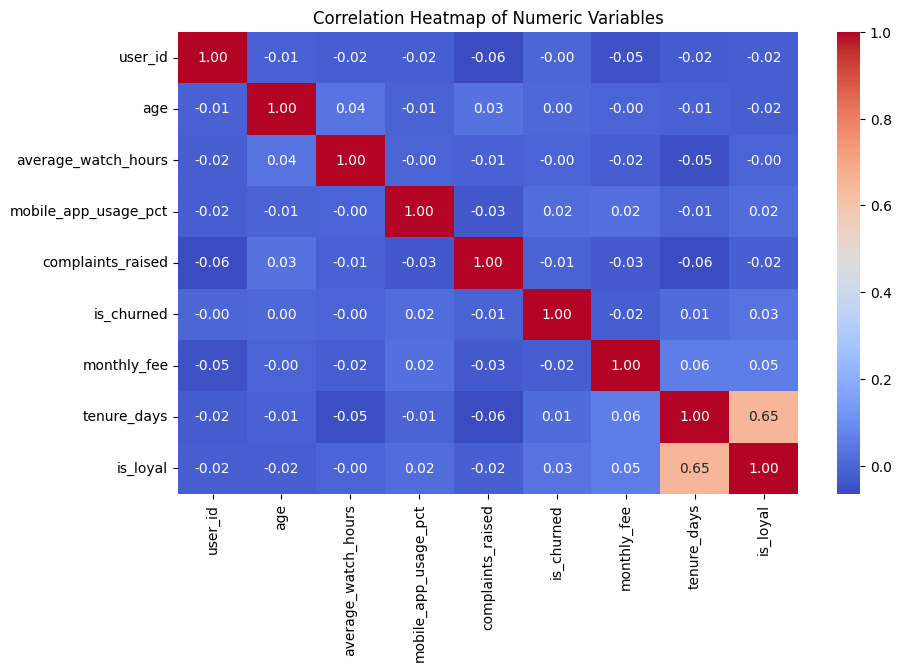

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

correlation heatmap indicates that most numerical variables have weak linear relationships with each other and with the churn variable

no single feature shows a strong correlation with 'is_churned', suggesting that churn behaviour is influenced by a combination of factors rather than one dominant variable

strong positive correlation is observed between 'tenure_days' and 'is_loyal' which is expected, as loyalty indicator is derived directly from tenure

overall, these results support the use of multivariate models such as logistic regression, which can capture combined effects that are not visible through pairwise correlation alone

####5.3 Visualising differences between churned and retained users
- visualisations were created to compare key behavioural and engagement metrics between churned and retained users
- these charts complement statistical tests and provide intuitive insights into churn patterns

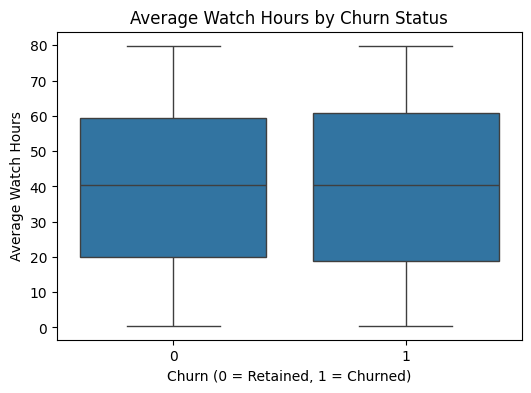

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_churned', y='average_watch_hours', data=df)
plt.title('Average Watch Hours by Churn Status')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Average Watch Hours')
plt.show()

boxplot compares average watch time between churned and retained users

both groups show similar median watch times of 40 hours and a wide overlap in their distributions

this indicates that watch time alone does not clearly differentiate churned users from retained users, which is consistent with the t-test results

to further explore churn patterns, a bar chart is created to compare churn between loyal and non-loyal users

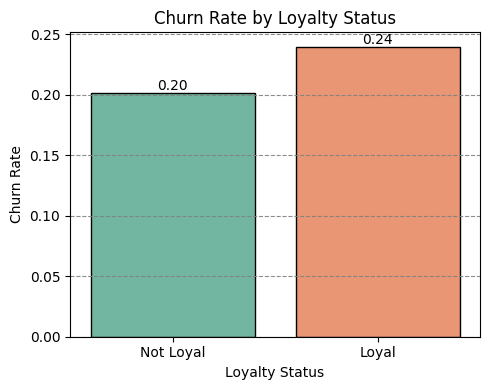

In [ ]:
churn_by_loyalty = (df.groupby('is_loyal')['is_churned'].mean().reset_index())

churn_by_loyalty['is_loyal'] = churn_by_loyalty['is_loyal'].map({
    0: 'Not Loyal',
    1: 'Loyal'
})

plt.figure(figsize=(5, 4))
ax = sns.barplot(
    x='is_loyal',
    y='is_churned',
    hue='is_loyal',
    data=churn_by_loyalty,
    palette='Set2',
    edgecolor='black',
    legend=False
)

ax.set_title('Churn Rate by Loyalty Status')
ax.set_xlabel('Loyalty Status')
ax.set_ylabel('Churn Rate')

ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.9 )

for bar in ax.patches:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height,
      f'{height:.2f}',
      ha='center',
      va='bottom'
  )

plt.tight_layout()
plt.show()

bar chart compares churn rates between loyal and non-loyal users

non-loyal users show a lower churn rate of 0.20, while loyal users show a meaningful churn rate of 0.24

this indicates that tenure alone does not fully explain churn behaviour and additional factors should be considered in predictive modelling

to further understand user behaviour, a histogram was created to examine the distribution of user tenure

this helps identify whether the dataset contains more short-term or long-term users

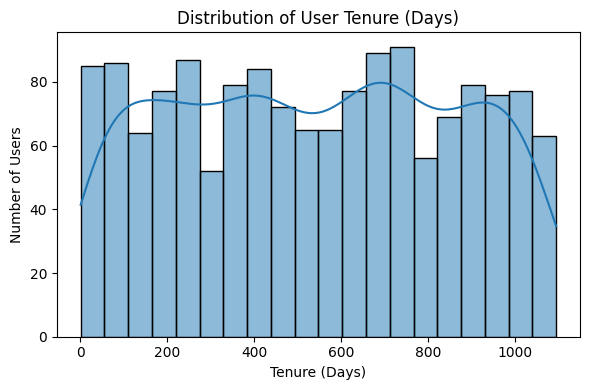

In [ ]:
plt.figure(figsize=(6, 4))

sns.histplot(df['tenure_days'], bins=20, kde=True)
plt.title('Distribution of User Tenure (Days)')
plt.xlabel('Tenure (Days)')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

histogram shows a broad distribution of user tenure, indicating that the dataset includes both newer and long-term users

this adversity suggests that churn behaviour may vary across different tenure stages, supporting the use of tenure-based features in predictive modelling

####6. Predictive modelling: Logistic regression (binary classification)
- logistic regression model is built to predict customer churn
- this model estimates the probability that user will churn based on their demographic, behavioural and subscription-related features

####6.1 Feature selection and target variable
- target variable for this model is 'is_churned'
- identifier and date-related columns were excluded from the feature set, as they do not provide predictive value

In [ ]:
X = df.drop(columns=['is_churned', 'user_id', 'signup_date', 'last_active_date'])
y = df['is_churned']
X.shape, y.shape

((1493, 18), (1493,))

####6.2 Train-test split
- dataset is split into training and testing sets to evaluate model performance on unseen data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

####6.3 Feature scaling
- numerical features were standardised to make sure variables on different scales contribute equally to the model

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

####6.4 Logistic regression model training
- the model is trained using scaled training data to learn the relationship between user features and churn probability

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg

LogisticRegression(max_iter=1000, random_state=42)

####6.5 Model evaluation
- model was evaluated using multiple classification metrics this includes accuracy, precision, recall, F1-score and ROC-AUC to assess its ability to predict churn

In [ ]:
#6.5.1 make predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#6.5.2 classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

accuracy, precision, recall, f1, roc_auc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.767379679144385, 0.0, 0.0, 0.0, np.float64(0.5441948015539269))

In [ ]:
#6.5.3 confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[287,   0],
       [ 87,   0]])

logistic regression model achieved an accuracy of approximately 77%

however, the model failed to identify any churned users, resulting in precision, recall, and F1-score values of zero

this outcome reflects the class imbalance in the dataset, where the majority of users are retained, while the accuracy appears high, it is misleading in
this context, as the model prioritises predicting the majority class and does
not effectively capture churn behaviour

ROC-AUC score of 0.54 suggests that the model has limited ability to distinguish between churned and retained users, indicating that further
model tuning or alternative approaches may be required



####6.6 Handling class imbalance
- to address class imbalance, a logistic regression model with balanced class weights was trained

In [ ]:
#6.6 classification metrics
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

log_reg_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
#predictions
y_pred_bal = log_reg_balanced.predict(X_test_scaled)
y_pred_proba_bal = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]

accuracy_bal = accuracy_score(y_test, y_pred_bal)
precision_bal = precision_score(y_test, y_pred_bal)
recall_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)

accuracy_bal, precision_bal, recall_bal, f1_bal, roc_auc_bal

confusion_matrix(y_test, y_pred_bal)

array([[145, 142],
       [ 40,  47]])

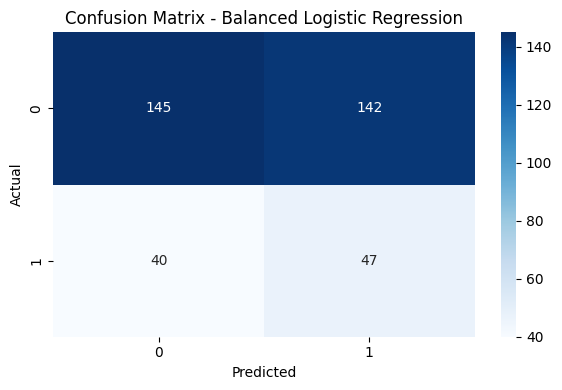

In [ ]:
#confusion matrix plot
cm_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Balanced Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

balanced logistic regression model shows a clear improvement in indentifying churned users compared to the baseline model

while the model introduces a higher number of false positives, it successfully captures a substantial proportion of actual churn cases, which is critical for effective churn prevention strategies

from a business context the cost of missing a churned customer is typically higher than the cost of targeting a retained user with a retention offer

####6.8 Classification Report

In [ ]:
# Step 5: Evaluate model
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.78      0.51      0.61       287
           1       0.25      0.54      0.34        87

    accuracy                           0.51       374
   macro avg       0.52      0.52      0.48       374
weighted avg       0.66      0.51      0.55       374



classification report shows that the balanced logistic regression model achieves a recall of 0.54 for churned users, meaning over half od actual churned cases are correctly identified

while precision for churn is lower, it indicates a higher number of false positives

overall accuracy is reduced due to the model prioritising churn detection over majority-class prediction, highlighting the importance of using multiple evaluation metrics rather than accuracy alone

####6.9 ROC curve and AUC
- it illustrates the trade-off between true positive and false positive across different classification thresholds
- the area under the curve (AUC) provides a summary measure of the model's ability to distinguish between churned and retained users

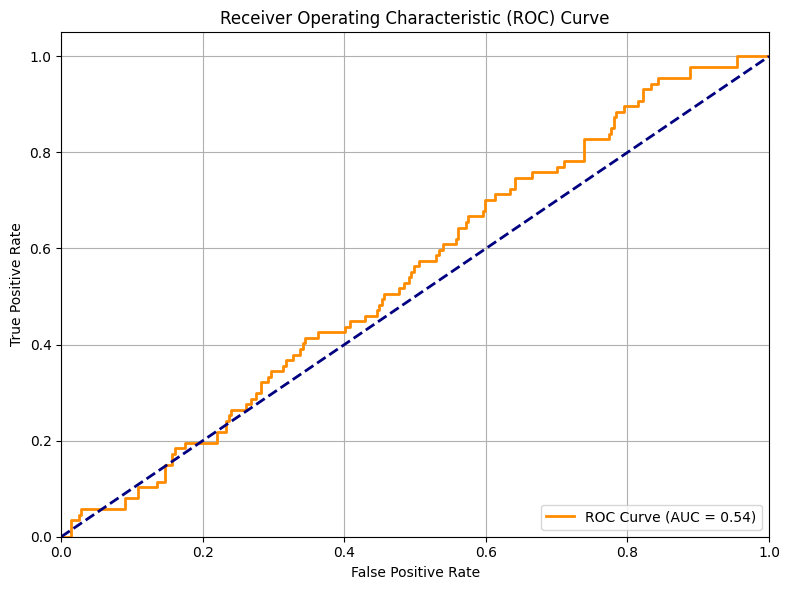

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_bal)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC Curve (AUC = {roc_auc:.2f})'
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

ROC curve indicates that the balanced logistic regression model performs better than random classifier which would have the AUC of 0.5

AUC of approx. 0.54 suggests a modest ability to distinguish between churned and retained users, which is reasonable given the complexity of churn behaviour and limited feature set

####6.10 Interpretation of Model coefficients
- coefficients of logistic regression model were examined to identify the most influential predictors of customer churn

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_balanced.coef_[0]
})

coef_df['Absolute_Value'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Value', ascending=False)

coef_df.head(10)

,Feature,Coefficient,Absolute_Value
8,gender_Other,-0.130859,0.130859
7,gender_Male,-0.130297,0.130297
6,is_loyal,0.104108,0.104108
12,country_UK,0.102125,0.102125
16,received_promotions_Yes,-0.088079,0.088079
11,country_India,0.070480,0.070480
3,complaints_raised,-0.049990,0.049990
14,subscription_type_Premium,-0.049902,0.049902
5,tenure_days,-0.041468,0.041468
1,average_watch_hours,-0.036609,0.036609


In [ ]:
print("Top Churn Predictors:")
for _, row in coef_df.head(5).iterrows():
    print(f"{row['Feature']:30s}: {row['Coefficient']:.3f}")

Top Churn Predictors:
gender_Other                  : -0.131
gender_Male                   : -0.130
is_loyal                      : 0.104
country_UK                    : 0.102
received_promotions_Yes       : -0.088


coefficient analysis indicates that demographic, geographic, and
engagement-related factors all contribute to churn risk

higher engagement, including longer tenure and greater watch time, is associated with reduced
churn, while receiving promotions also lowers churn likelihood

overall, the mix of positive and negative coefficients highlights that churn behaviour is influenced by multiple factors and is best captured using a multivariate modelling approach

####7. Linear regression - predicting average watch hours
- linear regression model is developed to predict users' average watch hours based on demographic, behavioural and subscription-related features
- this provides insight into factors that influence user engagement

####7.1 Feature selection and target variable
- target variable for this model is 'average_watch_hours'
- identifier and date-related columns were removed, as they do not contribute to predicting watch behaviour

In [ ]:
X_lr = df.drop(columns=['average_watch_hours',
                        'user_id',
                        'signup_date',
                        'last_active_date',
                        'is_churned'])

y_lr = df['average_watch_hours']

####7.2 Train-test split (linear regression)
- dataset is split into training and testing sets to evaluate the linear regression model on unseen data

In [ ]:
from sklearn.model_selection import train_test_split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.25, random_state=42
)

####7.3 Linear regression model training
- multivariate linear regression model is trained using selected features

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_lr, y_train_lr)

LinearRegression()

####7.4 - Model evaluation
- linear regression model is evaluated using R2 and root mean squared error (RMSE) to assess its predictive performance

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred_lr = lin_reg.predict(X_test_lr)

r2 = r2_score(y_test_lr, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae = mean_absolute_error(y_test_lr, y_pred_lr)

print("Linear Regression Results:")
print(f"R² Score : {r2:.3f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")

Linear Regression Results:
R² Score : -0.034
RMSE     : 22.96
MAE      : 19.51


linear regression model achieved a low R2 score, it shows that selected features explain little of the variation in average watch hours

high RMSE, suggests that user engagement is difficult to predict using linear relationships alone

MAE indicates the average deviation between predicted and actual watch time (average prediction error)

####7.5 Residual analysis
- residual plot is created to examine prediction errors and assess the assumptions of the linear regression model

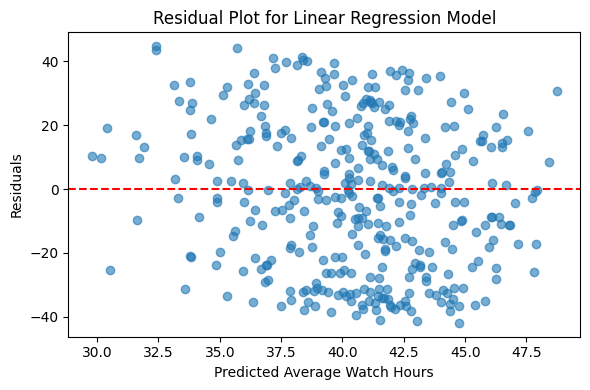

In [ ]:
residuals = y_test_lr - y_pred_lr

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Average Watch Hours')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression Model')
plt.tight_layout()
plt.show()

residual plot shows that errors are generally centred around zero, with no clear systematic pattern, sugggesting linear model form is reasonable

however, the wide dispersion of residuals indicates substantial prediction error, particularly at higher predicted watch hours, reinforcing limited predictive performance of the model

####7.6 Interpretation of coefficients

In [ ]:
coef_lr = pd.DataFrame({
    'Feature': X_lr.columns,
    'Coefficient': lin_reg.coef_
})

coef_lr['Absolute_Value'] = coef_lr['Coefficient'].abs()
coef_lr = coef_lr.sort_values(by='Absolute_Value', ascending=False)

coef_lr.head(10)

,Feature,Coefficient,Absolute_Value
6,gender_Male,-4.089926,4.089926
5,is_loyal,3.751979,3.751979
12,country_USA,3.450338,3.450338
10,country_India,3.308940,3.308940
13,subscription_type_Premium,-3.291217,3.291217
11,country_UK,2.555602,2.555602
15,received_promotions_Yes,1.326296,1.326296
8,country_France,1.159153,1.159153
14,subscription_type_Standard,0.557223,0.557223
2,complaints_raised,-0.485835,0.485835


In [ ]:
print("Top Feature Coefficients:")
for _, row in coef_lr.head(5).iterrows():
    print(f"{row['Feature']:30s}: {row['Coefficient']:.3f}")

Top Feature Coefficients:
gender_Male                   : -4.090
is_loyal                      : 3.752
country_USA                   : 3.450
country_India                 : 3.309
subscription_type_Premium     : -3.291


coefficient analysis identifies gender, loyalty status, geographic location and subscription type as the most influential predictors of average watch hours

positive coefficients are associated with increased viewing time, while negative coefficients indicate reduce engagement

despite identifying influential features, the overall power of this model stays limited, highlighting the complexity of user watch behaviour